#### This notebook demonstrates the use of InFoRM algorithms to mitigate bias for spectral clustering
InFoRM includes 3 algorithms, namely debiasing the input graph, debiasing the mining model and debiasing the mining result. We will show how to run all 3 algorithms for spectral clustering in this notebook.

### Get vanilla clustering membership matrix first

In [1]:
# load necessary packages
import pickle
import load_graph
import utils

import networkx as nx

from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh

In [2]:
def vanilla(name, v0):
    try:
        with open('result/sc/vanilla.pickle', 'rb') as f:
            udict = pickle.load(f)
    except:
        udict = dict()

    if name == 'ppi':
        data = load_graph.read_mat(name)
        graph = data['graph']
    else:
        graph = load_graph.read_graph(name)
    lcc = max(nx.connected_components(graph), key=len)  # take largest connected components
    adj = nx.to_scipy_sparse_matrix(graph, nodelist=lcc, dtype='float', format='csc')
    lap = laplacian(adj)
    lap *= -1
    _, u = eigsh(lap, which='LM', k=10, sigma=1.0, v0=v0[name])
    udict[name] = dict()
    udict[name]['eigenvectors'] = u

    with open('result/sc/vanilla.pickle', 'wb') as f:
        pickle.dump(udict, f, protocol=pickle.HIGHEST_PROTOCOL)

In [3]:
# load starting vector for decomposition
v0 = pickle.load(open('data/v0.pickle', 'rb'))

/tmp/ipykernel_264358/2622809428.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  v0 = pickle.load(open('data/v0.pickle', 'rb'))


In [4]:
# get vanilla clustering membership
vanilla(name='ppi', v0=v0)

/tmp/ipykernel_264358/1316422038.py:14: DeprecationWarning: 

The scipy.sparse array containers will be used instead of matrices
in Networkx 3.0. Use `to_scipy_sparse_array` instead.
  adj = nx.to_scipy_sparse_matrix(graph, nodelist=lcc, dtype='float', format='csc')


### Let's debias the input graph

In [5]:
# load debias model
from method.debias_graph import DebiasGraph

In [6]:
def debias_input_graph(name, v0, alpha=0.0, lr=0.0, metric=None):
    # load graph
    if name == 'ppi':
        data = load_graph.read_mat(name)
        graph = data['graph']
    else:
        graph = load_graph.read_graph(name)
    lcc = max(nx.connected_components(graph), key=len)  # take largest connected components
    init_adj = nx.to_scipy_sparse_matrix(graph, nodelist=lcc, dtype='float', format='csc')

    # build similarity matrix
    sim = utils.get_similarity_matrix(init_adj, metric=metric)

    # debias spectral clustering
    FairGraph = DebiasGraph()
    adj = FairGraph.spectral_clustering(init_adj, sim, alpha, ncluster=10, v0=v0[name], maxiter=100, lr=lr, tol=1e-6)
    lap = laplacian(adj)
    lap *= -1
    _, u = eigsh(lap, which='LM', k=10, sigma=1.0, v0=v0[name])

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print('Finished!')

    return u

In [7]:
v0 = pickle.load(open('data/v0.pickle', 'rb'))

# jaccard index
result = dict()
result['ppi'] = debias_input_graph(name='ppi', v0=v0, alpha=1e7, lr=0.05, metric='jaccard')
with open('result/sc/graph/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity
result = dict()
result['ppi'] = debias_input_graph(name='ppi', v0=v0, alpha=1e7, lr=0.05, metric='cosine')
with open('result/sc/graph/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

/tmp/ipykernel_264358/1577770493.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  v0 = pickle.load(open('data/v0.pickle', 'rb'))


/tmp/ipykernel_264358/3453089405.py:9: DeprecationWarning: 

The scipy.sparse array containers will be used instead of matrices
in Networkx 3.0. Use `to_scipy_sparse_array` instead.
  init_adj = nx.to_scipy_sparse_matrix(graph, nodelist=lcc, dtype='float', format='csc')
Debiasing Graph:  84%|████████▍ | 84/100 [19:07<03:38, 13.67s/it]


dataset: ppi	metric: jaccard similarity
Finished!


Debiasing Graph: 100%|██████████| 100/100 [21:23<00:00, 12.83s/it]


dataset: ppi	metric: cosine similarity
Finished!


### Let's debias the mining model

In [8]:
# load debias model
from method.debias_model import DebiasModel

In [9]:
def debias_mining_model(name, v0, alpha=0.0, metric=None):
    # load dataset
    if name == 'ppi':
        data = load_graph.read_mat(name)
        graph = data['graph']
    else:
        graph = load_graph.read_graph(name)
    lcc = max(nx.connected_components(graph), key=len)  # take largest connected components
    adj = nx.to_scipy_sparse_matrix(graph, nodelist=lcc, dtype='float', format='csc')

    # build similarity matrix
    sim = utils.get_similarity_matrix(adj, metric=metric)

    # debias spectral clustering
    FairModel = DebiasModel()
    # V, U = sc.debias_alg(adj, sim, alpha, ncluster=10, v0=v0[name])
    u = FairModel.spectral_clustering(adj, sim, alpha, ncluster=10, v0=v0[name])

    print('dataset: {}\t metric: {} similarity'.format(name, metric))
    print('Finished!')

    return u

In [10]:
alpha = 0.5
v0 = pickle.load(open('data/v0.pickle', 'rb'))
# jaccard index
result = dict()
result['ppi'] = debias_mining_model(name='ppi', v0=v0, alpha=alpha, metric='jaccard')
with open('result/sc/model/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_mining_model(name='ppi', v0=v0, alpha=alpha, metric='cosine')
with open('result/sc/model/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

/tmp/ipykernel_264358/1877967639.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  v0 = pickle.load(open('data/v0.pickle', 'rb'))
/tmp/ipykernel_264358/2927004789.py:9: DeprecationWarning: 

The scipy.sparse array containers will be used instead of matrices
in Networkx 3.0. Use `to_scipy_sparse_array` instead.
  adj = nx.to_scipy_sparse_matrix(graph, nodelist=lcc, dtype='float', format='csc')


dataset: ppi	 metric: jaccard similarity
Finished!
dataset: ppi	 metric: cosine similarity
Finished!


### Let's debias the mining result

In [11]:
# load debias model
from method.debias_result import DebiasResult

In [12]:
def debias_mining_result(name, vanilla, alpha=0.0, metric=None):
    # vanilla result
    u = vanilla[name]['eigenvectors']

    # load dataset
    if name == 'ppi':
        data = load_graph.read_mat(name)
        graph = data['graph']
    else:
        graph = load_graph.read_graph(name)
    cc = max(nx.connected_components(graph), key=len)  # take largest connected components
    adj = nx.to_scipy_sparse_matrix(graph, nodelist=cc, dtype='float', format='csc')

    # build similarity matrix
    sim = utils.get_similarity_matrix(adj, metric=metric)

    # debias spectral clustering
    FairResult = DebiasResult()
    u = FairResult.fit(u, sim, alpha)
    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print('Finished!')

    return u

In [13]:
alpha = 0.5

with open('result/sc/vanilla.pickle', 'rb') as f:
    vanilla = pickle.load(f)

# jaccard index
result = dict()
result['ppi'] = debias_mining_result(name='ppi', vanilla=vanilla, alpha=alpha, metric='jaccard')
with open('result/sc/result/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_mining_result(name='ppi', vanilla=vanilla, alpha=alpha, metric='cosine')
with open('result/sc/result/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

/tmp/ipykernel_264358/890288301.py:12: DeprecationWarning: 

The scipy.sparse array containers will be used instead of matrices
in Networkx 3.0. Use `to_scipy_sparse_array` instead.
  adj = nx.to_scipy_sparse_matrix(graph, nodelist=cc, dtype='float', format='csc')


dataset: ppi	metric: jaccard similarity
Finished!
dataset: ppi	metric: cosine similarity
Finished!


### Now, let's see how much we debiased and how good debiased results are

In [14]:
# load evaluation functions
from evaluate.sc import *

In [15]:
evaluate(name='ppi', metric='jaccard', task='graph')
evaluate(name='ppi', metric='cosine', task='graph')
evaluate(name='ppi', metric='jaccard', task='model')
evaluate(name='ppi', metric='cosine', task='model')
evaluate(name='ppi', metric='jaccard', task='result')
evaluate(name='ppi', metric='cosine', task='result')

{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(1.0345048797521668), 'nmi': np.float64(0.9137902163453485), 'bias': np.float64(0.1953445422126896)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.9334060666184424), 'nmi': np.float64(0.9137902163453485), 'bias': np.float64(0.24145779363833375)}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.9943213464406652), 'nmi': np.float64(0.7071461293418063), 'bias': np.float64(0.6702471197888358)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the mining model', 'diff': np.float64(0.8966720571839398), 'nmi': np.float64(0.6669405716467854), 'bias': np.float64(0.7522006156266914)}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining result', 'diff': np.float64(0.2418338751897767), 'nmi': np.float64(0.8346148936623693), 'bias': np.float6

{'dataset': 'ppi',
 'metric': 'cosine similarity',
 'task': 'debias the mining result',
 'diff': np.float64(0.34270967780629125),
 'nmi': np.float64(0.7670041294499387),
 'bias': np.float64(0.8736625361671752)}

{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(1.0345048797521668), 'nmi': np.float64(0.9137902163453485), 'bias': np.float64(0.1953445422126896)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.9334060666184424), 'nmi': np.float64(0.9137902163453485), 'bias': np.float64(0.24145779363833375)}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.9943213464406652), 'nmi': np.float64(0.7071461293418063), 'bias': np.float64(0.6702471197888358)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the mining model', 'diff': np.float64(0.8966720571839398), 'nmi': np.float64(0.6669405716467854), 'bias': np.float64(0.7522006156266914)}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining result', 'diff': np.float64(0.2418338751897767), 'nmi': np.float64(0.8346148936623693), 'bias': np.float6

,task,metric,diff,nmi,bias,label
0,graph,jaccard,1.034505,0.913790,0.195345,graph-jaccard
1,graph,cosine,0.933406,0.913790,0.241458,graph-cosine
2,model,jaccard,0.994321,0.707146,0.670247,model-jaccard
3,model,cosine,0.896672,0.666941,0.752201,model-cosine
4,result,jaccard,0.241834,0.834615,0.775058,result-jaccard
5,result,cosine,0.342710,0.767004,0.873663,result-cosine


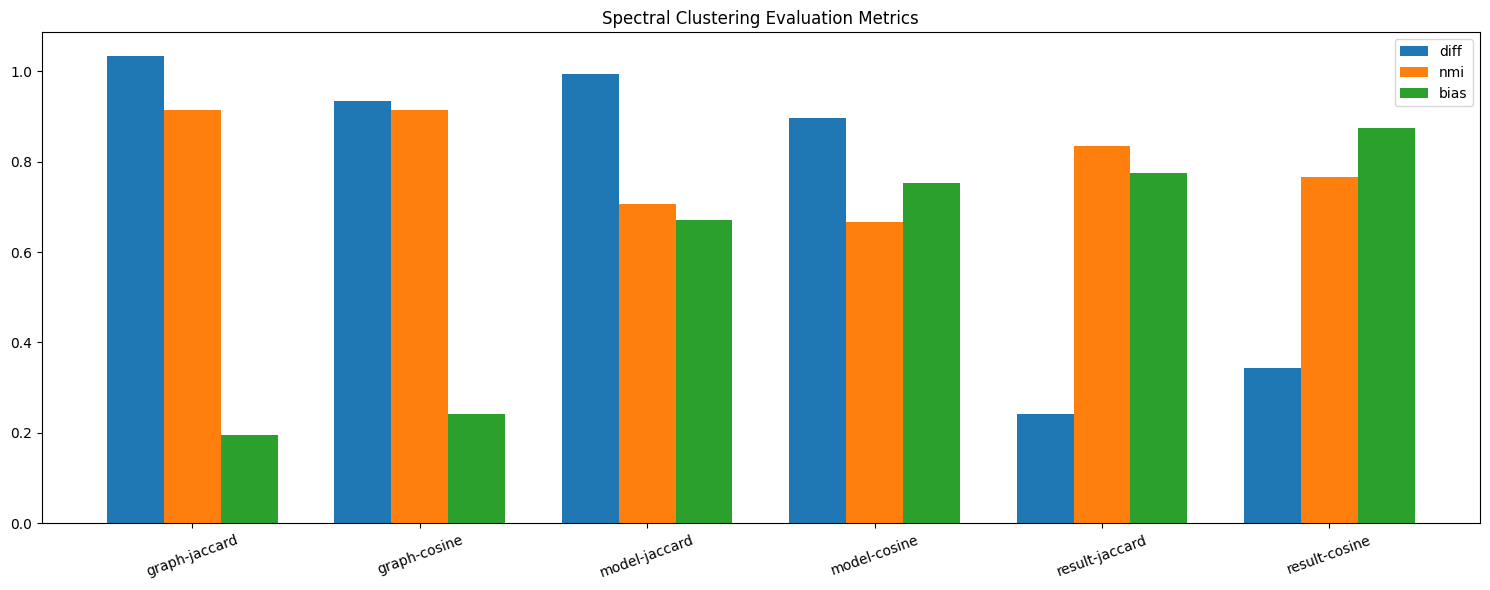

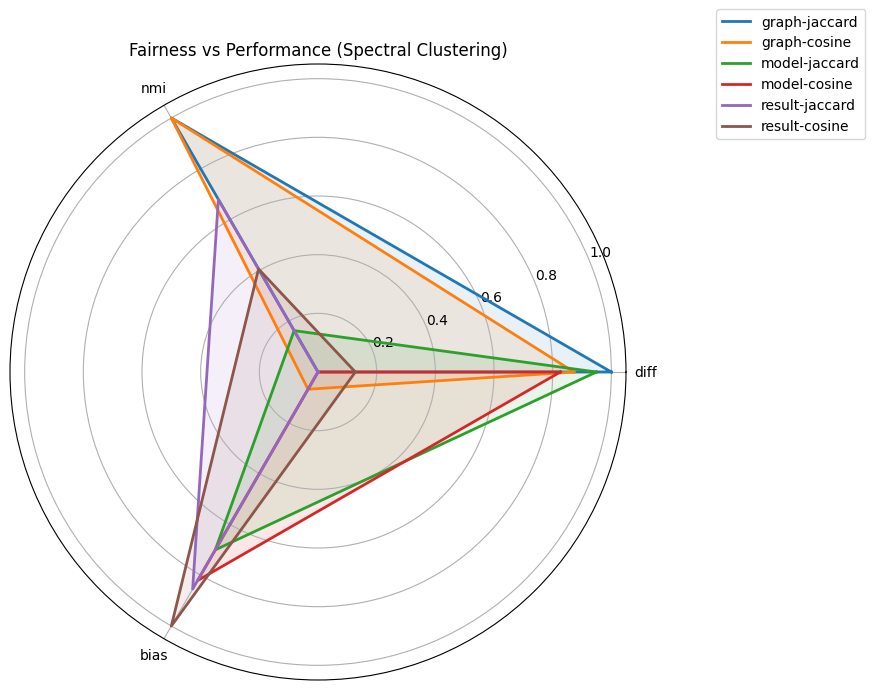

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# RUN EVALUATION
# =========================
results = []
configs = [
    ('jaccard', 'graph'), ('cosine', 'graph'),
    ('jaccard', 'model'), ('cosine', 'model'),
    ('jaccard', 'result'), ('cosine', 'result')
]

for metric, task in configs:
    r = evaluate(name='ppi', metric=metric, task=task)
    
    # Lấy đúng "nội tạng" của Spectral Clustering
    row = {
        'task': task,
        'metric': metric,
        'diff': float(r['diff']),
        'nmi': float(r['nmi']),      # NMI (Normalized Mutual Information)
        'bias': float(r['bias'])     # Spectral Clustering trả về 1 số bias duy nhất
    }
    results.append(row)

# =========================
# DATAFRAME (Đã khôi phục cơ thể)
# =========================
df = pd.DataFrame(results)
df['label'] = df['task'] + "-" + df['metric']
display(df)

# =========================
# BAR CHART
# =========================
# Cập nhật lại đúng hệ gen metrics cho biểu đồ
metrics = ['diff', 'nmi', 'bias']

x = np.arange(len(df))
width = 0.25 # Điều chỉnh độ rộng cột vì giờ chỉ có 3 cột

plt.figure(figsize=(15,6))
for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        df[metric],
        width=width,
        label=metric
    )

plt.xticks(
    x + width,
    df['label'],
    rotation=20
)

plt.title("Spectral Clustering Evaluation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# RADAR CHART
# =========================
radar_df = df.copy()

# normalize
for col in metrics:
    radar_df[col] = (radar_df[col] - radar_df[col].min()) / (radar_df[col].max() - radar_df[col].min())

categories = metrics
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for i in range(len(radar_df)):
    values = radar_df.loc[i, metrics].tolist()
    values += values[:1]
    
    ax.plot(
        angles,
        values,
        linewidth=2,
        label=radar_df.loc[i, 'label']
    )
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("Fairness vs Performance (Spectral Clustering)")
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.show()